# Frank-Wolfe Algorithm: Constrained Optimization over Polytopes

The **Frank-Wolfe algorithm** (also known as the conditional gradient method) solves smooth constrained optimization problems of the form
$$
\min_{x \in \mathcal{D}}\; f(x),
$$
where $\mathcal{D}$ is a compact convex set and $f$ is a smooth (differentiable) objective.

## Algorithm

At each iteration $k$, given the current iterate $x_k \in \mathcal{D}$:

1. **Linear minimization oracle (LMO):** Solve $s_k = \arg\min_{s \in \mathcal{D}} \langle \nabla f(x_k),\, s \rangle$.
2. **Update:** Move along the Frank-Wolfe direction:
$$
x_{k+1} = (1 - \gamma_k)\, x_k + \gamma_k\, s_k,
\quad \gamma_k = \frac{2}{k+2}.
$$

The key advantage is that the LMO over a polytope reduces to finding the vertex minimizing the linear form — an $O(|V|)$ operation.
The step size $\gamma_k = 2/(k+2)$ (with $k$ starting from $0$) ensures $O(1/k)$ convergence for smooth convex objectives.

## This Notebook

We minimize $f(x) = \frac{1}{2}\|x - t\|^2$ (squared distance to a **target** $t$ placed **outside** the feasible set $\mathcal{D}$), so the solution is the projection of $t$ onto $\mathcal{D}$.  
The gradient is simply $\nabla f(x) = x - t$.

We run the experiment on three polytopes: a **triangle**, a **square**, and a **pentagon**, starting from a point on the boundary (convex combination of two adjacent vertices, not the centroid).

## Setup and Frank-Wolfe implementation

We implement the Frank-Wolfe iteration for a quadratic objective.  
Given vertices $V = \{v_1,\ldots,v_m\}$ of a polytope and target $t \notin \mathcal{D}$:

- Gradient: $g_k = x_k - t$
- LMO: $j^* = \arg\min_j\; v_j^\top g_k$, i.e. the vertex most opposite to the gradient direction
- Step size: $\gamma_k = 2/(k+2)$ with $k = 0, 1, \ldots$
- Initial point: $x_0 = 0.4 v_0 + 0.6 v_1$ (boundary point, not centroid)

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = False
rng = np.random.default_rng(0)

OUT = Path("python/frank-wolfe"); OUT.mkdir(parents=True, exist_ok=True)
STATIC_SNAPSHOT = True

def fw(vertices, target, n_iter=80):
    """Frank-Wolfe for quadratic f(x) = 0.5*||x-target||^2 over polytope with given vertices."""
    # Start from boundary: convex combination of two adjacent vertices (NOT centroid)
    x = 0.4 * vertices[0] + 0.6 * vertices[1]
    traj = [x.copy()]
    for k in range(n_iter):
        g = x - target          # gradient of 0.5*||x-t||^2
        j = np.argmin(vertices @ g)  # LMO: vertex minimizing linear form
        s = vertices[j]
        gamma = 2.0 / (k + 2)   # step size, k starts from 0
        x = (1 - gamma) * x + gamma * s
        traj.append(x.copy())
    return np.array(traj)

# --- Define three polytopes ---
# Triangle
tri = np.array([[0, 1.5], [-1.3, -0.75], [1.3, -0.75]])

# Square
sq = np.array([[-1, -1], [1, -1], [1, 1], [-1, 1]])

# Pentagon: angles 2*pi*k/5, radius 1.2
ang = 2 * np.pi * np.arange(5) / 5
pent = 1.2 * np.c_[np.cos(ang), np.sin(ang)]

# Target: outside all three shapes
target = np.array([2.5, 1.8])

# Run FW on all three
traj_tri  = fw(tri,  target)
traj_sq   = fw(sq,   target)
traj_pent = fw(pent, target)

print(f"Triangle:  start={traj_tri[0]},  end={traj_tri[-1]}")
print(f"Square:    start={traj_sq[0]},   end={traj_sq[-1]}")
print(f"Pentagon:  start={traj_pent[0]}, end={traj_pent[-1]}")

Triangle:  start=[-0.78  0.15],  end=[0.48830247 0.65486111]
Square:    start=[ 0.2 -1. ],   end=[1. 1.]
Pentagon:  start=[0.70249224 0.68476069], end=[0.79769434 0.55372624]


## Visualization: trajectories over three polytopes

For each shape we display:
- **Blue filled polygon** (light): the feasible set $\mathcal{D}$
- **Blue boundary**: edges of the polytope
- **Black thick line**: the Frank-Wolfe optimization trajectory $\{x_k\}$
- **Green dot**: starting point $x_0$ (on the boundary)
- **Red $\times$**: target $t$ (outside the feasible set)

Notice that the trajectory rapidly moves along the boundary and converges to the projection of $t$ onto $\mathcal{D}$.

In [2]:
shapes = [(tri, traj_tri, "Triangle"), (sq, traj_sq, "Square"), (pent, traj_pent, "Pentagon")]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.7), constrained_layout=True)

for ax, (V, T, ttl) in zip(axes, shapes):
    # Filled polygon
    poly = MplPolygon(V, closed=True)
    pc = PatchCollection([poly], facecolor="tab:blue", alpha=0.12, edgecolor="none")
    ax.add_collection(pc)

    # Boundary (thin, so trajectory stays visible)
    P = np.vstack([V, V[0]])
    ax.plot(P[:, 0], P[:, 1], color="tab:blue", lw=1.2, zorder=2)

    # Trajectory — red with directional arrows every 10 steps
    ax.plot(T[:, 0], T[:, 1], color="tab:red", lw=2.2, zorder=5, label="trajectory")
    # Add arrows to show direction
    arrow_steps = np.linspace(0, len(T) - 2, 8, dtype=int)
    for k in arrow_steps:
        dx = T[k+1, 0] - T[k, 0]
        dy = T[k+1, 1] - T[k, 1]
        ax.annotate("", xy=(T[k+1, 0], T[k+1, 1]), xytext=(T[k, 0], T[k, 1]),
                    arrowprops=dict(arrowstyle="-|>", color="tab:red",
                                   lw=1.5, mutation_scale=12),
                    zorder=6)

    # Start point (green square)
    ax.scatter(T[0, 0], T[0, 1], color="tab:green", s=70, zorder=7,
               marker="s", label=r"start $x_0$")
    # End point (red dot)
    ax.scatter(T[-1, 0], T[-1, 1], color="crimson", s=70, zorder=7,
               marker="o", label=r"end $x_{80}$")
    # Target (red X, outside)
    ax.scatter(target[0], target[1], color="tomato", s=90, marker="*",
               linewidths=2, zorder=7, label=r"target $t$ (outside)")

    ax.set_aspect("equal")
    ax.set_title(ttl, fontsize=13)
    ax.legend(fontsize=8, loc="lower left")

    # Auto-fit limits with margin
    all_pts = np.vstack([V, T, [target]])
    xmn, xmx = all_pts[:, 0].min(), all_pts[:, 0].max()
    ymn, ymx = all_pts[:, 1].min(), all_pts[:, 1].max()
    margin = 0.3
    ax.set_xlim(xmn - margin, xmx + margin)
    ax.set_ylim(ymn - margin, ymx + margin)

fig.suptitle("Frank-Wolfe trajectories on three polytopes (target outside feasible set)", fontsize=12)
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.close(fig)

## Convergence analysis

The Frank-Wolfe gap $g_k = \max_{s \in \mathcal{D}} \langle \nabla f(x_k), x_k - s \rangle$ is a computable upper bound on $f(x_k) - f(x^*)$.  
For a $\beta$-smooth convex objective, the classical bound gives
$$
f(x_k) - f(x^*) \leq \frac{2 \beta R^2}{k + 2},
$$
where $R = \max_{x,y \in \mathcal{D}} \|x - y\|$ is the diameter of $\mathcal{D}$.

We plot the objective value $f(x_k) = \frac{1}{2}\|x_k - t\|^2$ vs. iteration for all three shapes.

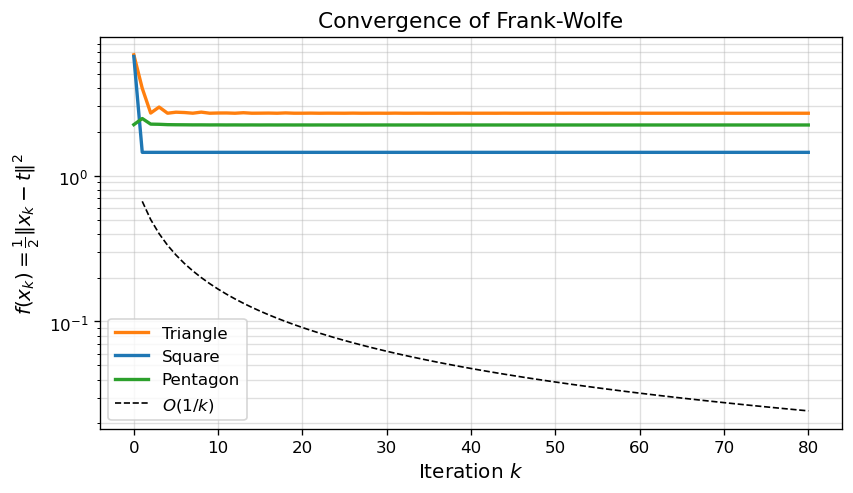

In [3]:
fig2, ax2 = plt.subplots(figsize=(7, 4), constrained_layout=True)

colors = ["tab:orange", "tab:blue", "tab:green"]
for (V, T, ttl), c in zip(shapes, colors):
    obj = 0.5 * np.sum((T - target) ** 2, axis=1)
    ax2.semilogy(obj, label=ttl, color=c, lw=2)

# Reference O(1/k) curve
ks = np.arange(1, len(traj_tri))
ax2.semilogy(ks, 2.0 / (ks + 2), "k--", lw=1, label=r"$O(1/k)$")

ax2.set_xlabel("Iteration $k$", fontsize=12)
ax2.set_ylabel(r"$f(x_k) = \frac{1}{2}\|x_k - t\|^2$", fontsize=12)
ax2.set_title("Convergence of Frank-Wolfe", fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, which="both", alpha=0.4)

## Takeaways

- The **Frank-Wolfe algorithm** solves smooth constrained optimization by iterating vertex-seeking linear programs over the feasible set.
- When $\mathcal{D}$ is a polytope, the LMO is a simple vertex enumeration — no projection is needed.
- The step rule $\gamma_k = 2/(k+2)$ yields provable $O(1/k)$ convergence for smooth convex $f$.
- Starting from a **boundary point** (not the interior centroid) better illustrates the "vertex-hopping" behavior characteristic of Frank-Wolfe.
- With the target **outside** $\mathcal{D}$, the algorithm converges to the Euclidean projection of $t$ onto $\mathcal{D}$.

## Bibliography

- M. Frank and P. Wolfe, "An algorithm for quadratic programming," *Naval Research Logistics Quarterly*, 3(1–2):95–110, 1956.
- M. Jaggi, "Revisiting Frank-Wolfe: Projection-free sparse convex optimization," *ICML*, 2013.
- S. Lacoste-Julien and M. Jaggi, "On the global linear convergence of Frank-Wolfe optimization variants," *NeurIPS*, 2015.